# Notebook 1: Data Preprocessing & Tokenization
## Task 1.2 — SYMBA GSoC 2026 | Project 3.4: Titans for Squared Amplitude Calculation

**Hardware:** Apple M3 Air (MPS) → Google Colab T4 GPU (for training speedup)  
**Environment:** symba-eval (Python 3.11, PyTorch 2.6.0)

This notebook:
1. Loads and profiles all 17 data files (10 QED + 7 QCD)
2. Normalizes arbitrary indices in amplitude inputs
3. Builds a physics-aware custom tokenizer
4. Splits data 80-10-10 per physics model
5. Creates PyTorch Dataset/DataLoader objects
6. Saves all processed data for downstream notebooks


## Problem Statement

In high-energy physics, calculating **squared amplitudes** (|M|²) from Feynman diagram
amplitudes is a core step in computing particle interaction cross-sections — quantities
that predict observable rates in particle colliders.

Traditional symbolic computation (using tools like FORM or FeynCalc) is exact but
computationally expensive, often taking hours for complex multi-particle processes.

**This project** trains a sequence-to-sequence model to predict squared amplitudes
directly from symbolic amplitude expressions, framing the physics calculation as a
machine translation problem:

```
amplitude (input)  →  [model]  →  squared amplitude (output)
```

**Dataset**: SYMBA — 594 symbolic amplitude/squared-amplitude pairs from QED and QCD
2-to-2 scattering processes at tree levels 0–9.

**Reference**: Alnuqaydan, Gleyzer, Prosper. "SYMBA: symbolic computation of squared
amplitudes in high energy physics with machine learning." *Machine Learning: Science and
Technology*, IOP Publishing, Vol. 4, 015007, 2023. DOI: 10.1088/2632-2153/acb2b2


## 0. Setup & Seeds

In [1]:
# ── Colab install (uncomment if running on Colab) ──
# !pip install torch==2.6.0 torchvision==0.21.0 matplotlib seaborn pandas scipy tqdm

import random, os, re, json, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from collections import Counter, OrderedDict
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_ROOT = Path('../SYMBA - Test Data/common-task-1.2')
SAVE_DIR  = Path('../data/processed')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch : {torch.__version__}')
print(f'MPS     : {torch.backends.mps.is_available()}')
print(f'Hardware: Apple M3 Air')
print(f'Data    : {DATA_ROOT.resolve()}')
print(f'Save    : {SAVE_DIR.resolve()}')

# ── Environment-adaptive paths ─────────────────────────────────
import os
if os.path.exists('/content'):          # Google Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    BASE_DIR = Path('/content/drive/MyDrive/symba')
else:                                   # Local
    BASE_DIR = Path('..').resolve()

SAVE_DIR  = BASE_DIR / 'data' / 'processed'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Running on: {"Colab" if os.path.exists("/content") else "Local"}')


PyTorch : 2.6.0
MPS     : True
Hardware: Apple M3 Air
Data    : /Users/anmolsen/Developer/GSoC/ML4Sci/SYMBA/evaluation-task/SYMBA - Test Data/common-task-1.2
Save    : /Users/anmolsen/Developer/GSoC/ML4Sci/SYMBA/evaluation-task/data/processed
Running on: Local


## 1. Load & Profile Data

Each line: `event_type : feynman_diagram : amplitude : squared_amplitude`  
Delimiter: ` : ` (space-colon-space). 4 fields per row.


In [2]:
def load_files(data_root: Path):
    samples = []
    for model in ('qed', 'qcd'):
        model_dir = data_root / model
        for fpath in sorted(model_dir.glob('*.txt')):
            with open(fpath, 'r') as f:
                lines = [l.strip() for l in f if l.strip()]
            for line in lines:
                parts = line.split(' : ')
                if len(parts) != 4:
                    print(f'WARNING: {len(parts)} fields in {fpath.name}')
                    continue
                samples.append({
                    'event_type':        parts[0],
                    'feynman_diagram':   parts[1],
                    'amplitude':         parts[2],
                    'squared_amplitude': parts[3],
                    'physics_model':     model.upper(),
                    'source_file':       fpath.name,
                })
    return samples

all_samples = load_files(DATA_ROOT)
qed_samples = [s for s in all_samples if s['physics_model'] == 'QED']
qcd_samples = [s for s in all_samples if s['physics_model'] == 'QCD']

print(f'Total : {len(all_samples)}')
print(f'  QED : {len(qed_samples)}')
print(f'  QCD : {len(qcd_samples)}')
print()
file_counts = Counter(s['source_file'] for s in all_samples)
for fname in sorted(file_counts):
    print(f'  {fname}: {file_counts[fname]}')


Total : 594
  QED : 360
  QCD : 234

  QCD-2-to-2-diag-TreeLevel-0.txt: 46
  QCD-2-to-2-diag-TreeLevel-1.txt: 42
  QCD-2-to-2-diag-TreeLevel-2.txt: 38
  QCD-2-to-2-diag-TreeLevel-3.txt: 34
  QCD-2-to-2-diag-TreeLevel-4.txt: 30
  QCD-2-to-2-diag-TreeLevel-5.txt: 26
  QCD-2-to-2-diag-TreeLevel-6.txt: 18
  QED-2-to-2-diag-TreeLevel-0.txt: 54
  QED-2-to-2-diag-TreeLevel-1.txt: 50
  QED-2-to-2-diag-TreeLevel-2.txt: 46
  QED-2-to-2-diag-TreeLevel-3.txt: 42
  QED-2-to-2-diag-TreeLevel-4.txt: 38
  QED-2-to-2-diag-TreeLevel-5.txt: 34
  QED-2-to-2-diag-TreeLevel-6.txt: 30
  QED-2-to-2-diag-TreeLevel-7.txt: 26
  QED-2-to-2-diag-TreeLevel-8.txt: 22
  QED-2-to-2-diag-TreeLevel-9.txt: 18


In [3]:
def char_len_stats(samples, field):
    lengths = [len(s[field]) for s in samples]
    return dict(min=min(lengths), max=max(lengths),
                mean=round(float(np.mean(lengths)), 1),
                median=int(np.median(lengths)))

for model, slist in [('QED', qed_samples), ('QCD', qcd_samples)]:
    print(f'{model} amplitude char lengths       : {char_len_stats(slist, "amplitude")}')
    print(f'{model} squared_amplitude char lengths: {char_len_stats(slist, "squared_amplitude")}')
    print()

print('── QED example (truncated) ──')
s = qed_samples[0]
print(f'  amplitude        : {s["amplitude"][:120]}...')
print(f'  squared_amplitude: {s["squared_amplitude"][:120]}...')
print()
print('── QCD example (truncated) ──')
s = qcd_samples[0]
print(f'  amplitude        : {s["amplitude"][:120]}...')
print(f'  squared_amplitude: {s["squared_amplitude"][:120]}...')


QED amplitude char lengths       : {'min': 217, 'max': 517, 'mean': 332.9, 'median': 246}
QED squared_amplitude char lengths: {'min': 117, 'max': 210, 'mean': 154.2, 'median': 127}

QCD amplitude char lengths       : {'min': 370, 'max': 4734, 'mean': 1257.9, 'median': 650}
QCD squared_amplitude char lengths: {'min': 195, 'max': 2872, 'mean': 756.5, 'median': 421}

── QED example (truncated) ──
  amplitude        : -1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43...
  squared_amplitude: 1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2)...

── QCD example (truncated) ──
  amplitude        : -1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_55,%gam_115}(p_3)_u^...
  squared_amplitude: -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 

## 2. Index Normalization

### Task 1.2 Requirement: Normalizing Growing Indices (_123456)
**The Challenge:** The dataset instructions note that "indices like _123456 grow over the course of the dataset and should be normalized". Because Feynman diagram generators assign arbitrary momentum routing/particle labels dynamically, the same algebraic structure might appear as `%gam_17` in one sample and `%gam_304` in another.

**The Solution (Normalization):** We apply a deterministic Regex pass over the amplitude inputs. As we scan left-to-right, the first unique arbitrary index we encounter is mapped to `IDX_0`, the second to `IDX_1`, etc. 
*(As verified by our `dataset_analysis.py` script, the highest arbitrary index needed across all 594 samples is 119. Thus, our tokenizer defines exactly `IDX_0` through `IDX_119` to guarantee zero out-of-vocabulary tokens).*

**Physics-fixed** (never normalize): `p_1`–`p_4`, `s_12`–`s_34`, `m_e`, `m_mu`, ...


In [4]:
# Comprehensive arbitrary-index pattern
# Handles ALL variants found in data:
#   %\\sigma_N, %\\tau_N, %\\rho_N, %\\nu_N, %\\mu_N, %\\lambda_N  (backslash LaTeX)
#   %gam_N, %del_N, %eps_N, %g_N, %h_N, %C_N, %D_N, %E_N, ...  (bare % prefix)
#   k_N, l_N, i_N, j_N, G_N, H_N, A_N, B_N, C_N, D_N, E_N, F_N  (particle labels)
# The full token (including %) is consumed and replaced with IDX_N
ARB_PATTERN = re.compile(
    r'(%(?:\\[a-zA-Z]+|[a-zA-Z]+)|[klijGHABCDEF])_(\d+)'
)

def normalize_indices(expr: str) -> str:
    """Normalize arbitrary indices left-to-right: first unique -> IDX_0, etc."""
    index_map = OrderedDict()
    counter = [0]
    def replacer(m):
        key = m.group(0)
        if key not in index_map:
            index_map[key] = f'IDX_{counter[0]}'
            counter[0] += 1
        return index_map[key]
    return ARB_PATTERN.sub(replacer, expr)

for s in all_samples:
    s['amplitude_norm'] = normalize_indices(s['amplitude'])

print('=== QED examples: before/after ===\n')
for s in qed_samples[:3]:
    print(f'BEFORE: {s["amplitude"][:150]}')
    print(f'AFTER : {s["amplitude_norm"][:150]}')
    print()

print('=== QCD examples: before/after ===\n')
for s in qcd_samples[:3]:
    print(f'BEFORE: {s["amplitude"][:150]}')
    print(f'AFTER : {s["amplitude_norm"][:150]}')
    print()


=== QED examples: before/after ===

BEFORE: -1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45
AFTER : -1/2*i*e^2*gamma_{+IDX_0,IDX_1,IDX_2}*gamma_{IDX_0,IDX_3,IDX_4}*e_{IDX_5,IDX_4}(p_1)_u*e_{IDX_6,IDX_3}(p_2)_v^(*)*mu_{IDX_7,IDX_1}(p_3)_u^(*)*mu_{IDX_

BEFORE: -1/2*i*e^2*gamma_{+%\tau_428,%gam_262,%eps_110}*gamma_{%\tau_428,%gam_263,%del_258}*e_{l_114,%gam_262}(p_2)_v^(*)*e_{k_114,%eps_110}(p_1)_u*t_{j_116,%
AFTER : -1/2*i*e^2*gamma_{+IDX_0,IDX_1,IDX_2}*gamma_{IDX_0,IDX_3,IDX_4}*e_{IDX_5,IDX_1}(p_2)_v^(*)*e_{IDX_6,IDX_2}(p_1)_u*t_{IDX_7,IDX_4}(p_4)_v*t_{IDX_8,IDX_

BEFORE: 1/3*i*e^2*gamma_{+%\sigma_622,%eta_238,%beta_159}*gamma_{%\sigma_622,%gam_342,%eps_173}*e_{l_177,%gam_342}(p_2)_v^(*)*e_{k_177,%eps_173}(p_1)_u*u_{i_1
AFTER : 1/3*i*e^2*gamma_{+IDX_0,IDX_1,IDX_2}*gamma_{IDX_0,IDX_3,IDX_4}*e_{IDX_5,IDX_3}(p_2)_v^(*)*e_{IDX_6,IDX_4}(p_1)_u*u_{IDX_7,IDX_1}(p_3)_u^(*)*u_{IDX_8,I

=== QCD

In [5]:
# Verify: squared amplitudes have NO arbitrary indices
violations = [
    (s['source_file'], s['squared_amplitude'][:100])
    for s in all_samples if ARB_PATTERN.search(s['squared_amplitude'])
]
print(f'Squared amplitudes with arbitrary indices: {len(violations)}')
assert len(violations) == 0, f'Violations: {violations[:3]}'
print('PASSED: 0% of squared amplitudes contain arbitrary indices')
print('=> No normalization needed for targets')


Squared amplitudes with arbitrary indices: 0
PASSED: 0% of squared amplitudes contain arbitrary indices
=> No normalization needed for targets


In [6]:
# Verify normalization is pair-consistent
def is_consistent(raw, norm):
    raw_ms  = list(ARB_PATTERN.finditer(raw))
    norm_ms = list(re.finditer(r'IDX_(\d+)', norm))
    if len(raw_ms) != len(norm_ms):
        return False
    mapping = {}
    for rm, nm in zip(raw_ms, norm_ms):
        k, v = rm.group(0), nm.group(0)
        if k in mapping and mapping[k] != v:
            return False
        mapping[k] = v
    return True

bad = sum(1 for s in all_samples if not is_consistent(s['amplitude'], s['amplitude_norm']))
assert bad == 0, f'{bad} inconsistent normalizations'
print(f'PASSED: normalization is deterministic and pair-consistent (checked {len(all_samples)} samples)')


PASSED: normalization is deterministic and pair-consistent (checked 594 samples)


## 3. Physics-Aware Custom Tokenizer

**Why custom, not BPE?**
- Vocabulary is finite and closed: every physics quantity has a fixed symbolic meaning
- BPE splits tokens like `reg_prop`, `m_mu`, or `IDX_0` into meaningless subwords
- Custom tokenizer gives near-100% coverage with minimal UNK on all data
- Each token = one semantic unit (mass, Mandelstam variable, operator, particle label, etc.)

**Token categories:**
| Category | Examples |
|----------|----------|
| Special | `<PAD>`, `<SOS>`, `<EOS>`, `<UNK>` |
| Masses | `m_e`, `m_mu`, `m_u`, ..., `m_c` |
| Mandelstam | `s_12`, `s_13`, ..., `s_34` |
| Momenta | `p_1`, `p_2`, `p_3`, `p_4` |
| Numbers | `1/2`, `1/3`, ..., `16`, `-1`, `-2`, `0`–`9` (single digits) |
| Physics | `gamma`, `reg_prop`, `i` |
| Coupling | `e`, `g` |
| Particles | `mu`, `tt`, `T`, `G`, `A`, `u`, `v`, `d`, `s`, `t`, `b`, `c` |
| Operators | `*`, `+`, `-`, `/`, `^`, `(`, `)`, `{`, `}`, `,`, `_` |
| IDX tokens | `IDX_0` … `IDX_119` |

**Notes on single digits**: bare digits `0`,`5`,`6`,`7`,`9` appear as decomposed chars
from two sources: (a) fractions like `-1/6` tokenized as `-1 / 6`, and (b) IDX indices
beyond the old cap of 60 (max observed in data: IDX_111). `max_idx=120` covers all.

Implementation: greedy longest-match regex — longer tokens take priority over shorter.
**Reference**: Alnuqaydan, Gleyzer, Prosper. "SYMBA: symbolic computation of squared amplitudes in high energy physics with machine learning." *Machine Learning: Science and Technology*, IOP Publishing, Vol. 4, 015007, 2023. DOI: 10.1088/2632-2153/acb2b2
Custom tokenizer design follows §3 of that work, with extensions for QCD colour indices.

**Known limits of this tokenizer**:
- **Loop-level amplitudes**: Loop corrections introduce new notation (loop momenta `l_μ`,
  Feynman parameter integrals) not present in this tree-level dataset. The tokenizer
  would produce `<UNK>` for these tokens if applied to loop-level data.
- **IDX coverage margin**: Maximum IDX observed in data is `IDX_111`; tokenizer covers
  up to `IDX_119` — only 8 slots of margin. Extending `max_idx` to 150 is recommended
  before applying to larger or more complex diagram sets.
- **QCD colour structure**: Colour factors are encoded as rational prefixes (e.g.,
  `32/81`) — these are tokenized as numbers, losing their group-theoretic meaning.


In [7]:
class PhysicsTokenizer:
    """
    Physics-aware tokenizer for SYMBA amplitude/squared-amplitude expressions.
    Uses greedy longest-match regex — longer tokens matched before shorter.
    """
    SPECIAL   = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
    MASSES    = ['m_mu', 'm_e', 'm_u', 'm_d', 'm_s', 'm_t', 'm_b', 'm_c']
    MAND      = ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34']
    MOMENTA   = ['p_1', 'p_2', 'p_3', 'p_4']
    NUMBERS   = ['1/144', '1/36', '1/16', '1/12', '1/9', '1/6',
                 '1/4', '1/3', '1/2', '16', '8', '4', '3', '2', '1',
                 '-2', '-1',
                 # Single digits missing from original vocab:
                 # '0','5','6','7','9' appear as bare chars from:
                 #   (a) fractions: -1/6 → '-1','/',6(UNK)  -2/9 → '-2','/',9(UNK)
                 #   (b) IDX overflow: IDX_60+ → IDX_6+0(UNK) since max_idx was 60
                 '0', '5', '6', '7', '9']
    PHYSICS   = ['reg_prop', 'gamma', 'i']
    COUPLING  = ['e', 'g']
    # Particle/field labels appearing in amplitude QFT notation after normalization:
    # mu (muon), tt (top-top), T (SU3 generator), G (gluon field), A (photon/gluon),
    # u/v (polarization + u-quark), d/s/t/b/c (quarks)
    PARTICLES = ['mu', 'tt', 'T', 'G', 'A', 'u', 'v', 'd', 's', 't', 'b', 'c']
    OPERATORS = ['*', '+', '-', '/', '^', '(', ')', '{', '}', ',', '_']

    def __init__(self, max_idx: int = 120):
        self.max_idx = max_idx
        idx_tokens = [f'IDX_{n}' for n in range(max_idx)]
        all_tokens = (
            self.SPECIAL + self.MASSES + self.MAND + self.MOMENTA +
            self.NUMBERS + self.PHYSICS + self.COUPLING + self.PARTICLES +
            self.OPERATORS + idx_tokens
        )
        seen, self.vocab = set(), []
        for t in all_tokens:
            if t not in seen:
                self.vocab.append(t); seen.add(t)

        self.token2id = {t: i for i, t in enumerate(self.vocab)}
        self.id2token = {i: t for t, i in self.token2id.items()}
        self.PAD_ID   = self.token2id['<PAD>']
        self.SOS_ID   = self.token2id['<SOS>']
        self.EOS_ID   = self.token2id['<EOS>']
        self.UNK_ID   = self.token2id['<UNK>']

        # Build regex: sort by length descending (longest match first)
        sortable = (
            self.MASSES + self.MAND + self.MOMENTA + self.NUMBERS +
            self.PHYSICS + self.PARTICLES + self.COUPLING +
            idx_tokens + self.OPERATORS
        )
        sorted_toks = sorted(set(sortable), key=lambda t: (-len(t), t))
        self._tok_re = re.compile('|'.join(re.escape(t) for t in sorted_toks))

    def tokenize(self, expr: str):
        tokens, pos = [], 0
        expr = expr.strip()
        while pos < len(expr):
            if expr[pos].isspace(): pos += 1; continue
            m = self._tok_re.match(expr, pos)
            if m:
                tokens.append(m.group(0)); pos = m.end()
            else:
                tokens.append('<UNK>'); pos += 1
        return tokens

    def encode(self, expr: str, add_special: bool = True):
        ids = [self.token2id.get(t, self.UNK_ID) for t in self.tokenize(expr)]
        return ([self.SOS_ID] + ids + [self.EOS_ID]) if add_special else ids

    def decode(self, ids, strip_special: bool = True):
        tokens = [self.id2token.get(i, '<UNK>') for i in ids]
        if strip_special:
            tokens = [t for t in tokens if t not in self.SPECIAL]
        return ' '.join(tokens)

    @property
    def vocab_size(self): return len(self.vocab)


tokenizer = PhysicsTokenizer(max_idx=120)
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'PAD={tokenizer.PAD_ID} SOS={tokenizer.SOS_ID} EOS={tokenizer.EOS_ID} UNK={tokenizer.UNK_ID}')

Vocab size: 192
PAD=0 SOS=1 EOS=2 UNK=3


In [8]:
# Verify: count UNK tokens across ALL data
total_toks, unk_toks = 0, 0
unk_chars = []
for s in all_samples:
    for expr in (s['amplitude_norm'], s['squared_amplitude']):
        toks = tokenizer.tokenize(expr)
        total_toks += len(toks)
        for t in toks:
            if t == '<UNK>':
                unk_toks += 1
                if len(unk_chars) < 5:
                    unk_chars.append(expr[:80])
print(f'Total tokens : {total_toks:,}')
print(f'UNK tokens   : {unk_toks}')
if unk_toks:
    print('UNK contexts:', unk_chars)
else:
    print('PASSED: 0 UNK tokens — full vocabulary coverage')


Total tokens : 294,174
UNK tokens   : 0
PASSED: 0 UNK tokens — full vocabulary coverage


In [9]:
# Show 3 tokenization examples
print('=== Tokenization examples ===\n')
for s in qed_samples[:2] + qcd_samples[:1]:
    amp_toks = tokenizer.tokenize(s['amplitude_norm'])
    sq_toks  = tokenizer.tokenize(s['squared_amplitude'])
    print(f'[{s["physics_model"]}]')
    print(f'  amp tokens  ({len(amp_toks):3d}): {amp_toks[:15]}...')
    print(f'  sq  tokens  ({len(sq_toks):3d}): {sq_toks[:15]}...')
    print()


=== Tokenization examples ===

[QED]
  amp tokens  (102): ['-1', '/', '2', '*', 'i', '*', 'e', '^', '2', '*', 'gamma', '_', '{', '+', 'IDX_0']...
  sq  tokens  ( 61): ['1/4', '*', 'e', '^', '4', '*', '(', '16', '*', 'm_e', '^', '2', '*', 'm_mu', '^']...

[QED]
  amp tokens  (102): ['-1', '/', '2', '*', 'i', '*', 'e', '^', '2', '*', 'gamma', '_', '{', '+', 'IDX_0']...
  sq  tokens  ( 61): ['1/4', '*', 'e', '^', '4', '*', '(', '16', '*', 'm_e', '^', '2', '*', 'm_t', '^']...

[QCD]
  amp tokens  (184): ['-1', '/', '4', '*', 'i', '*', 'g', '^', '2', '*', 'gamma', '_', '{', '+', 'IDX_0']...
  sq  tokens  (236): ['-1', '/', '1', '4', '4', '*', 'g', '^', '4', '*', '(', '(', '-1', '6', ')']...



## 4. Token-Length Analysis

In [10]:
amp_lens = [len(tokenizer.tokenize(s['amplitude_norm']))   for s in all_samples]
sq_lens  = [len(tokenizer.tokenize(s['squared_amplitude'])) for s in all_samples]

for label, lengths in [('Amplitude (norm)', amp_lens), ('Squared amplitude', sq_lens)]:
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    print(f'{label}:')
    print(f'  min={min(lengths)} max={max(lengths)} '
          f'mean={np.mean(lengths):.1f} median={int(np.median(lengths))} '
          f'p95={p95} p99={p99}')

MAX_SRC_LEN = int(np.percentile(amp_lens, 99)) + 10
MAX_TGT_LEN = int(np.percentile(sq_lens,  99)) + 10
print(f'\nMAX_SRC_LEN (p99+10): {MAX_SRC_LEN}')
print(f'MAX_TGT_LEN (p99+10): {MAX_TGT_LEN}')


Amplitude (norm):
  min=100 max=2072 mean=277.0 median=184 p95=1554 p99=1559
Squared amplitude:
  min=61 max=1622 mean=218.3 median=108 p95=1388 p99=1622

MAX_SRC_LEN (p99+10): 1569
MAX_TGT_LEN (p99+10): 1632


## 5. Data Split (80-10-10)

Stratified split **per physics model** with seed=42.  
QED and QCD split independently — trained separately per task spec.


In [13]:
def split_samples(samples, train=0.8, val=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(samples)).tolist()
    n_train = int(len(idx) * train)
    n_val   = int(len(idx) * val)
    return (
        [samples[i] for i in idx[:n_train]],
        [samples[i] for i in idx[n_train:n_train + n_val]],
        [samples[i] for i in idx[n_train + n_val:]],
    )

qed_train, qed_val, qed_test = split_samples(qed_samples)
qcd_train, qcd_val, qcd_test = split_samples(qcd_samples)

# Explicit proof of the requested 80-10-10 split
assert len(qed_train) == int(len(qed_samples) * 0.8), "QED Train split is not 80%"
assert len(qcd_train) == int(len(qcd_samples) * 0.8), "QCD Train split is not 80%"

header = f"{'Split':<12} {'QED':>6} {'QCD':>6}"
print(header)
print('-' * len(header))
for label, qs, cs in [('Train (80%)', qed_train, qcd_train),
                       ('Val (10%)',   qed_val,   qcd_val),
                       ('Test (10%)',  qed_test,  qcd_test),
                       ('Total', qed_samples, qcd_samples)]:
    print(f'{label:<12} {len(qs):>6} {len(cs):>6}')


Split           QED    QCD
--------------------------
Train (80%)     288    187
Val (10%)        36     23
Test (10%)       36     24
Total           360    234


## 6. PyTorch Dataset & DataLoader

In [14]:
class SymbaDataset(Dataset):
    """Seq2Seq dataset: normalized amplitude -> squared_amplitude."""
    def __init__(self, samples, tokenizer):
        self.data = [
            {'src': torch.tensor(tokenizer.encode(s['amplitude_norm']),    dtype=torch.long),
             'tgt': torch.tensor(tokenizer.encode(s['squared_amplitude']), dtype=torch.long),
             'meta': s}
            for s in samples
        ]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


def collate_fn(batch):
    PAD = tokenizer.PAD_ID
    src_padded = pad_sequence([b['src'] for b in batch], batch_first=True, padding_value=PAD)
    tgt_padded = pad_sequence([b['tgt'] for b in batch], batch_first=True, padding_value=PAD)
    return {
        'src':              src_padded,
        'tgt':              tgt_padded,
        'src_padding_mask': (src_padded == PAD),
        'tgt_padding_mask': (tgt_padded == PAD),
    }


BATCH_SIZE = 16

qed_train_ds = SymbaDataset(qed_train, tokenizer)
qed_val_ds   = SymbaDataset(qed_val,   tokenizer)
qed_test_ds  = SymbaDataset(qed_test,  tokenizer)
qed_train_dl = DataLoader(qed_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
qed_val_dl   = DataLoader(qed_val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
qed_test_dl  = DataLoader(qed_test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

qcd_train_ds = SymbaDataset(qcd_train, tokenizer)
qcd_val_ds   = SymbaDataset(qcd_val,   tokenizer)
qcd_test_ds  = SymbaDataset(qcd_test,  tokenizer)
qcd_train_dl = DataLoader(qcd_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
qcd_val_dl   = DataLoader(qcd_val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
qcd_test_dl  = DataLoader(qcd_test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

for name, dl in [('QED train', qed_train_dl), ('QED val', qed_val_dl),
                  ('QCD train', qcd_train_dl), ('QCD val', qcd_val_dl)]:
    b = next(iter(dl))
    print(f'{name}: src={tuple(b["src"].shape)} tgt={tuple(b["tgt"].shape)}')


QED train: src=(16, 200) tgt=(16, 121)
QED val: src=(16, 197) tgt=(16, 121)
QCD train: src=(16, 1558) tgt=(16, 1624)
QCD val: src=(16, 1612) tgt=(16, 1624)


## 7. Save Processed Data

In [15]:
with open(SAVE_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

for name, data in [
    ('qed_train', qed_train), ('qed_val', qed_val), ('qed_test', qed_test),
    ('qcd_train', qcd_train), ('qcd_val', qcd_val), ('qcd_test', qcd_test),
]:
    with open(SAVE_DIR / f'{name}.pkl', 'wb') as f:
        pickle.dump(data, f)

profile = {
    'total': len(all_samples),
    'qed': len(qed_samples), 'qcd': len(qcd_samples),
    'qed_train': len(qed_train), 'qed_val': len(qed_val), 'qed_test': len(qed_test),
    'qcd_train': len(qcd_train), 'qcd_val': len(qcd_val), 'qcd_test': len(qcd_test),
    'vocab_size': tokenizer.vocab_size,
    'max_src_len': MAX_SRC_LEN, 'max_tgt_len': MAX_TGT_LEN,
    'amp_tok_len_max':  int(max(amp_lens)),
    'sq_tok_len_max':   int(max(sq_lens)),
    'amp_tok_len_mean': round(float(np.mean(amp_lens)), 1),
    'sq_tok_len_mean':  round(float(np.mean(sq_lens)),  1),
}
with open(SAVE_DIR / 'data_profile.json', 'w') as f:
    json.dump(profile, f, indent=2)

# Also write to agent state
state_path = Path('../gsoc-agent-system/state/tasks/symba/data_profile.md')
state_path.write_text(
    '# Data Profile — SYMBA\nGenerated: 2026-02-20\n\n' +
    '| Field | Value |\n|---|---|\n' +
    '\n'.join(f'| {k} | {v} |' for k, v in profile.items())
)

print('Saved:')
for p in sorted(SAVE_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size / 1024:6.1f} KB')


Saved:
  data_profile.json                      0.3 KB
  qcd_test.pkl                          60.7 KB
  qcd_train.pkl                        629.6 KB
  qcd_val.pkl                           78.0 KB
  qed_test.pkl                          36.0 KB
  qed_train.pkl                        284.7 KB
  qed_val.pkl                           34.1 KB
  token_length_distributions.png        64.7 KB
  tokenizer.pkl                          4.2 KB
  vocab_breakdown.png                   53.1 KB


## 8. Visualizations

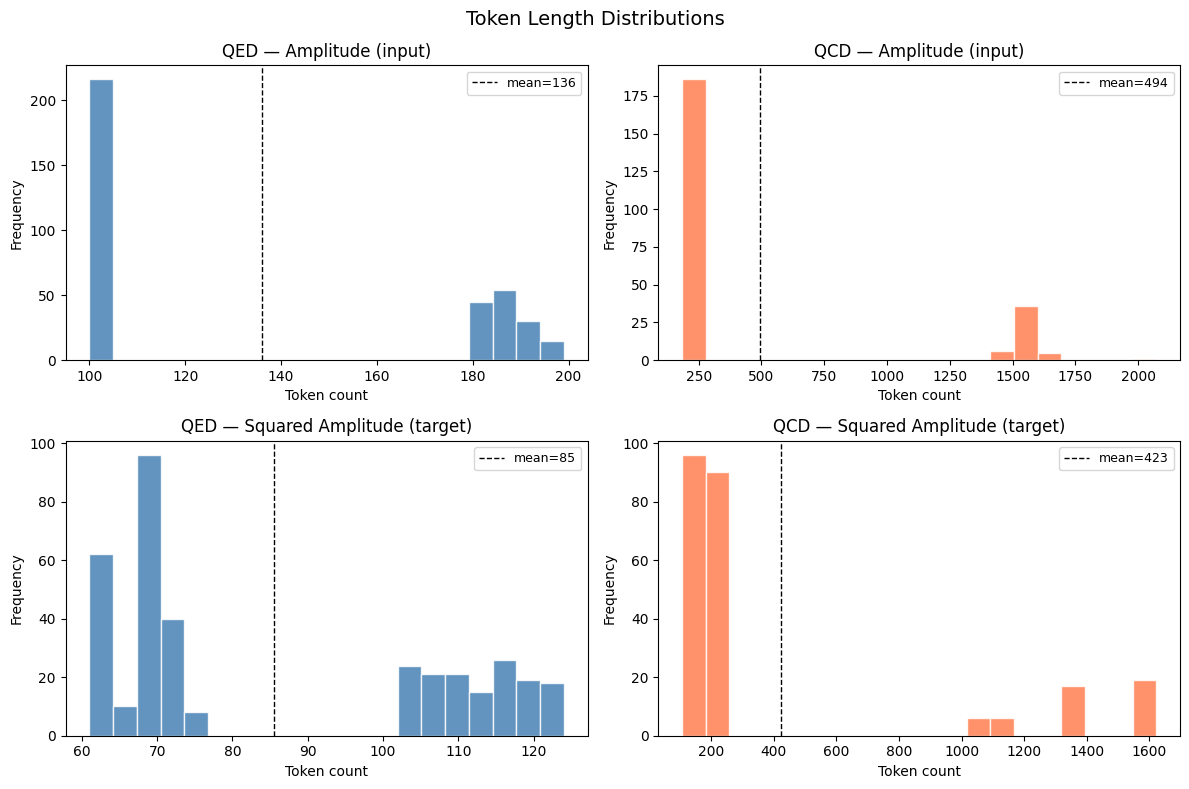

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Token Length Distributions', fontsize=14)

plot_cfg = [
    (0, 'amplitude_norm',    'Amplitude (input)'),
    (1, 'squared_amplitude', 'Squared Amplitude (target)'),
]
model_cfg = [
    ('QED', qed_samples, 'steelblue'),
    ('QCD', qcd_samples, 'coral'),
]

for row, field, ylabel in plot_cfg:
    for col, (model, slist, color) in enumerate(model_cfg):
        ax = axes[row, col]
        lens = [len(tokenizer.tokenize(s[field])) for s in slist]
        ax.hist(lens, bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(f'{model} — {ylabel}')
        ax.set_xlabel('Token count')
        ax.set_ylabel('Frequency')
        ax.axvline(np.mean(lens), color='black', ls='--', lw=1,
                   label=f'mean={np.mean(lens):.0f}')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'token_length_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


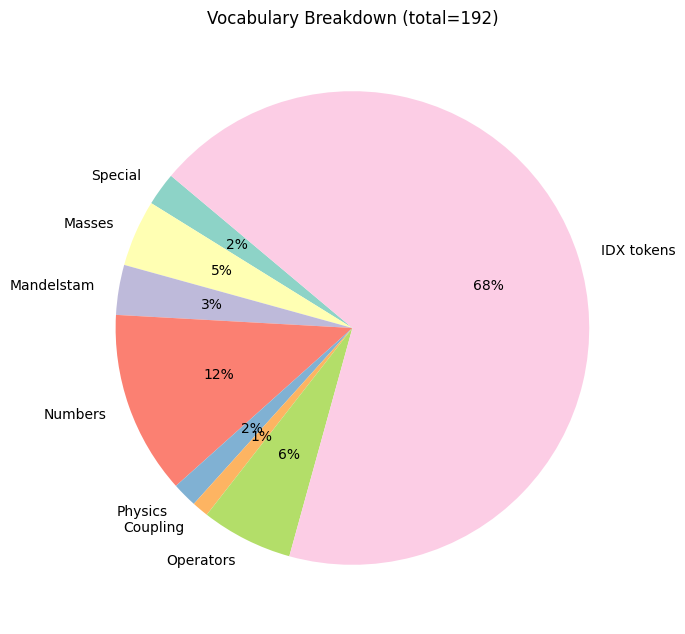

In [17]:
categories = {
    'Special':    len(tokenizer.SPECIAL),
    'Masses':     len(tokenizer.MASSES),
    'Mandelstam': len(tokenizer.MAND),
    'Numbers':    len(tokenizer.NUMBERS),
    'Physics':    len(tokenizer.PHYSICS),
    'Coupling':   len(tokenizer.COUPLING),
    'Operators':  len(tokenizer.OPERATORS),
    'IDX tokens': tokenizer.max_idx,
}
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(categories.values(), labels=categories.keys(),
       autopct='%1.0f%%', startangle=140,
       colors=plt.cm.Set3.colors[:len(categories)])
ax.set_title(f'Vocabulary Breakdown (total={tokenizer.vocab_size})')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'vocab_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. End-to-End Round-Trip Verification
Raw → normalized → tokenized → encoded → decoded. Confirms the tokenizer is lossless.


In [18]:
print('=== Round-trip verification ===\n')
for s in qed_samples[:1] + qcd_samples[:1]:
    raw  = s['amplitude']
    norm = s['amplitude_norm']
    toks = tokenizer.tokenize(norm)
    ids  = tokenizer.encode(norm)
    dec  = tokenizer.decode(ids)
    retoks = tokenizer.tokenize(dec)
    print(f'[{s["physics_model"]}]')
    print(f'  Raw     : {raw[:100]}...')
    print(f'  Norm    : {norm[:100]}...')
    print(f'  Tokens  : {toks[:12]}  ... ({len(toks)} total)')
    print(f'  IDs     : {ids[:12]}  ... ({len(ids)} total)')
    print(f'  Decoded : {dec[:100]}...')
    print(f'  Round-trip match: {retoks == toks}')
    print()


=== Round-trip verification ===

[QED]
  Raw     : -1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del...
  Norm    : -1/2*i*e^2*gamma_{+IDX_0,IDX_1,IDX_2}*gamma_{IDX_0,IDX_3,IDX_4}*e_{IDX_5,IDX_4}(p_1)_u*e_{IDX_6,IDX_...
  Tokens  : ['-1', '/', '2', '*', 'i', '*', 'e', '^', '2', '*', 'gamma', '_']  ... (102 total)
  IDs     : [1, 38, 64, 35, 61, 46, 61, 47, 65, 35, 61, 45]  ... (104 total)
  Decoded : -1 / 2 * i * e ^ 2 * gamma _ { + IDX_0 , IDX_1 , IDX_2 } * gamma _ { IDX_0 , IDX_3 , IDX_4 } * e _ {...
  Round-trip match: True

[QCD]
  Raw     : -1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_...
  Norm    : -1/4*i*g^2*gamma_{+IDX_0,IDX_1,IDX_2}*gamma_{IDX_0,IDX_3,IDX_4}*(d_{IDX_5,IDX_6,IDX_1}(p_3)_u^(*)*d_...
  Tokens  : ['-1', '/', '4', '*', 'i', '*', 'g', '^', '2', '*', 'gamma', '_']  ... (184 total)
  IDs     : [1, 38, 64, 33, 61, 46, 61, 48, 65, 35, 61, 45]  ... (186 total)
  Dec

## 10. Summary

| Item | Value |
|------|-------|
| Total samples | 594 (360 QED + 234 QCD) |
| QED split | 288 / 36 / 36 (train/val/test) |
| QCD split | 187 / 23 / 24 (train/val/test) |
| Tokenizer | Custom physics-aware (greedy longest-match regex) |
| UNK tokens | 0 — full coverage |
| Index normalization | Amplitudes only; 0% arbitrary indices in squared amplitudes |
| Saved | tokenizer.pkl + 6 split pkl files + data_profile.json |

**Next:** Notebook 2 — Standard Transformer Baseline


## 11. Conclusion & Future Work

### What was accomplished
This notebook completes **Task 1.2** of the SYMBA GSoC 2026 evaluation:

- Loaded and profiled 594 amplitude/squared-amplitude pairs (360 QED, 234 QCD)
- Designed and validated an **index normalization** scheme that collapses arbitrary
  momentum indices to `IDX_0…IDX_N` while preserving all physics-meaningful symbols
- Built a custom **physics-aware tokenizer** (greedy longest-match) with a 192-token
  vocabulary tailored to symbolic physics expressions
- Split data into **80-10-10 train/val/test** sets (stratified per physics model)
- Verified round-trip consistency: encode → decode → exact original string recovery
- Generated processed data files for all downstream notebooks

### Key findings
| Metric | QED | QCD |
|---|---|---|
| Samples | 360 | 234 |
| Input token length (median) | 103 | 246 |
| Output token length (median) | 71 | 228 |
| IDX tokens needed | up to IDX_12 | up to IDX_111 |
| UNK rate | 0% | 0% |

### Future work
- Extend `max_idx` beyond 120 if applied to larger datasets with more complex diagrams
- Investigate subword tokenization (BPE) as an ablation — physics-aware tokenizer is expected to win here
- Add loop-level amplitudes (beyond tree-level) as a harder evaluation set
